In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Initial Data Inspection

In [36]:
df = pd.read_csv('../data/train.csv')

# Check for missing values
print(df.isnull().sum())

# Basic stats for numerical columns
display(df.describe())
df.head()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


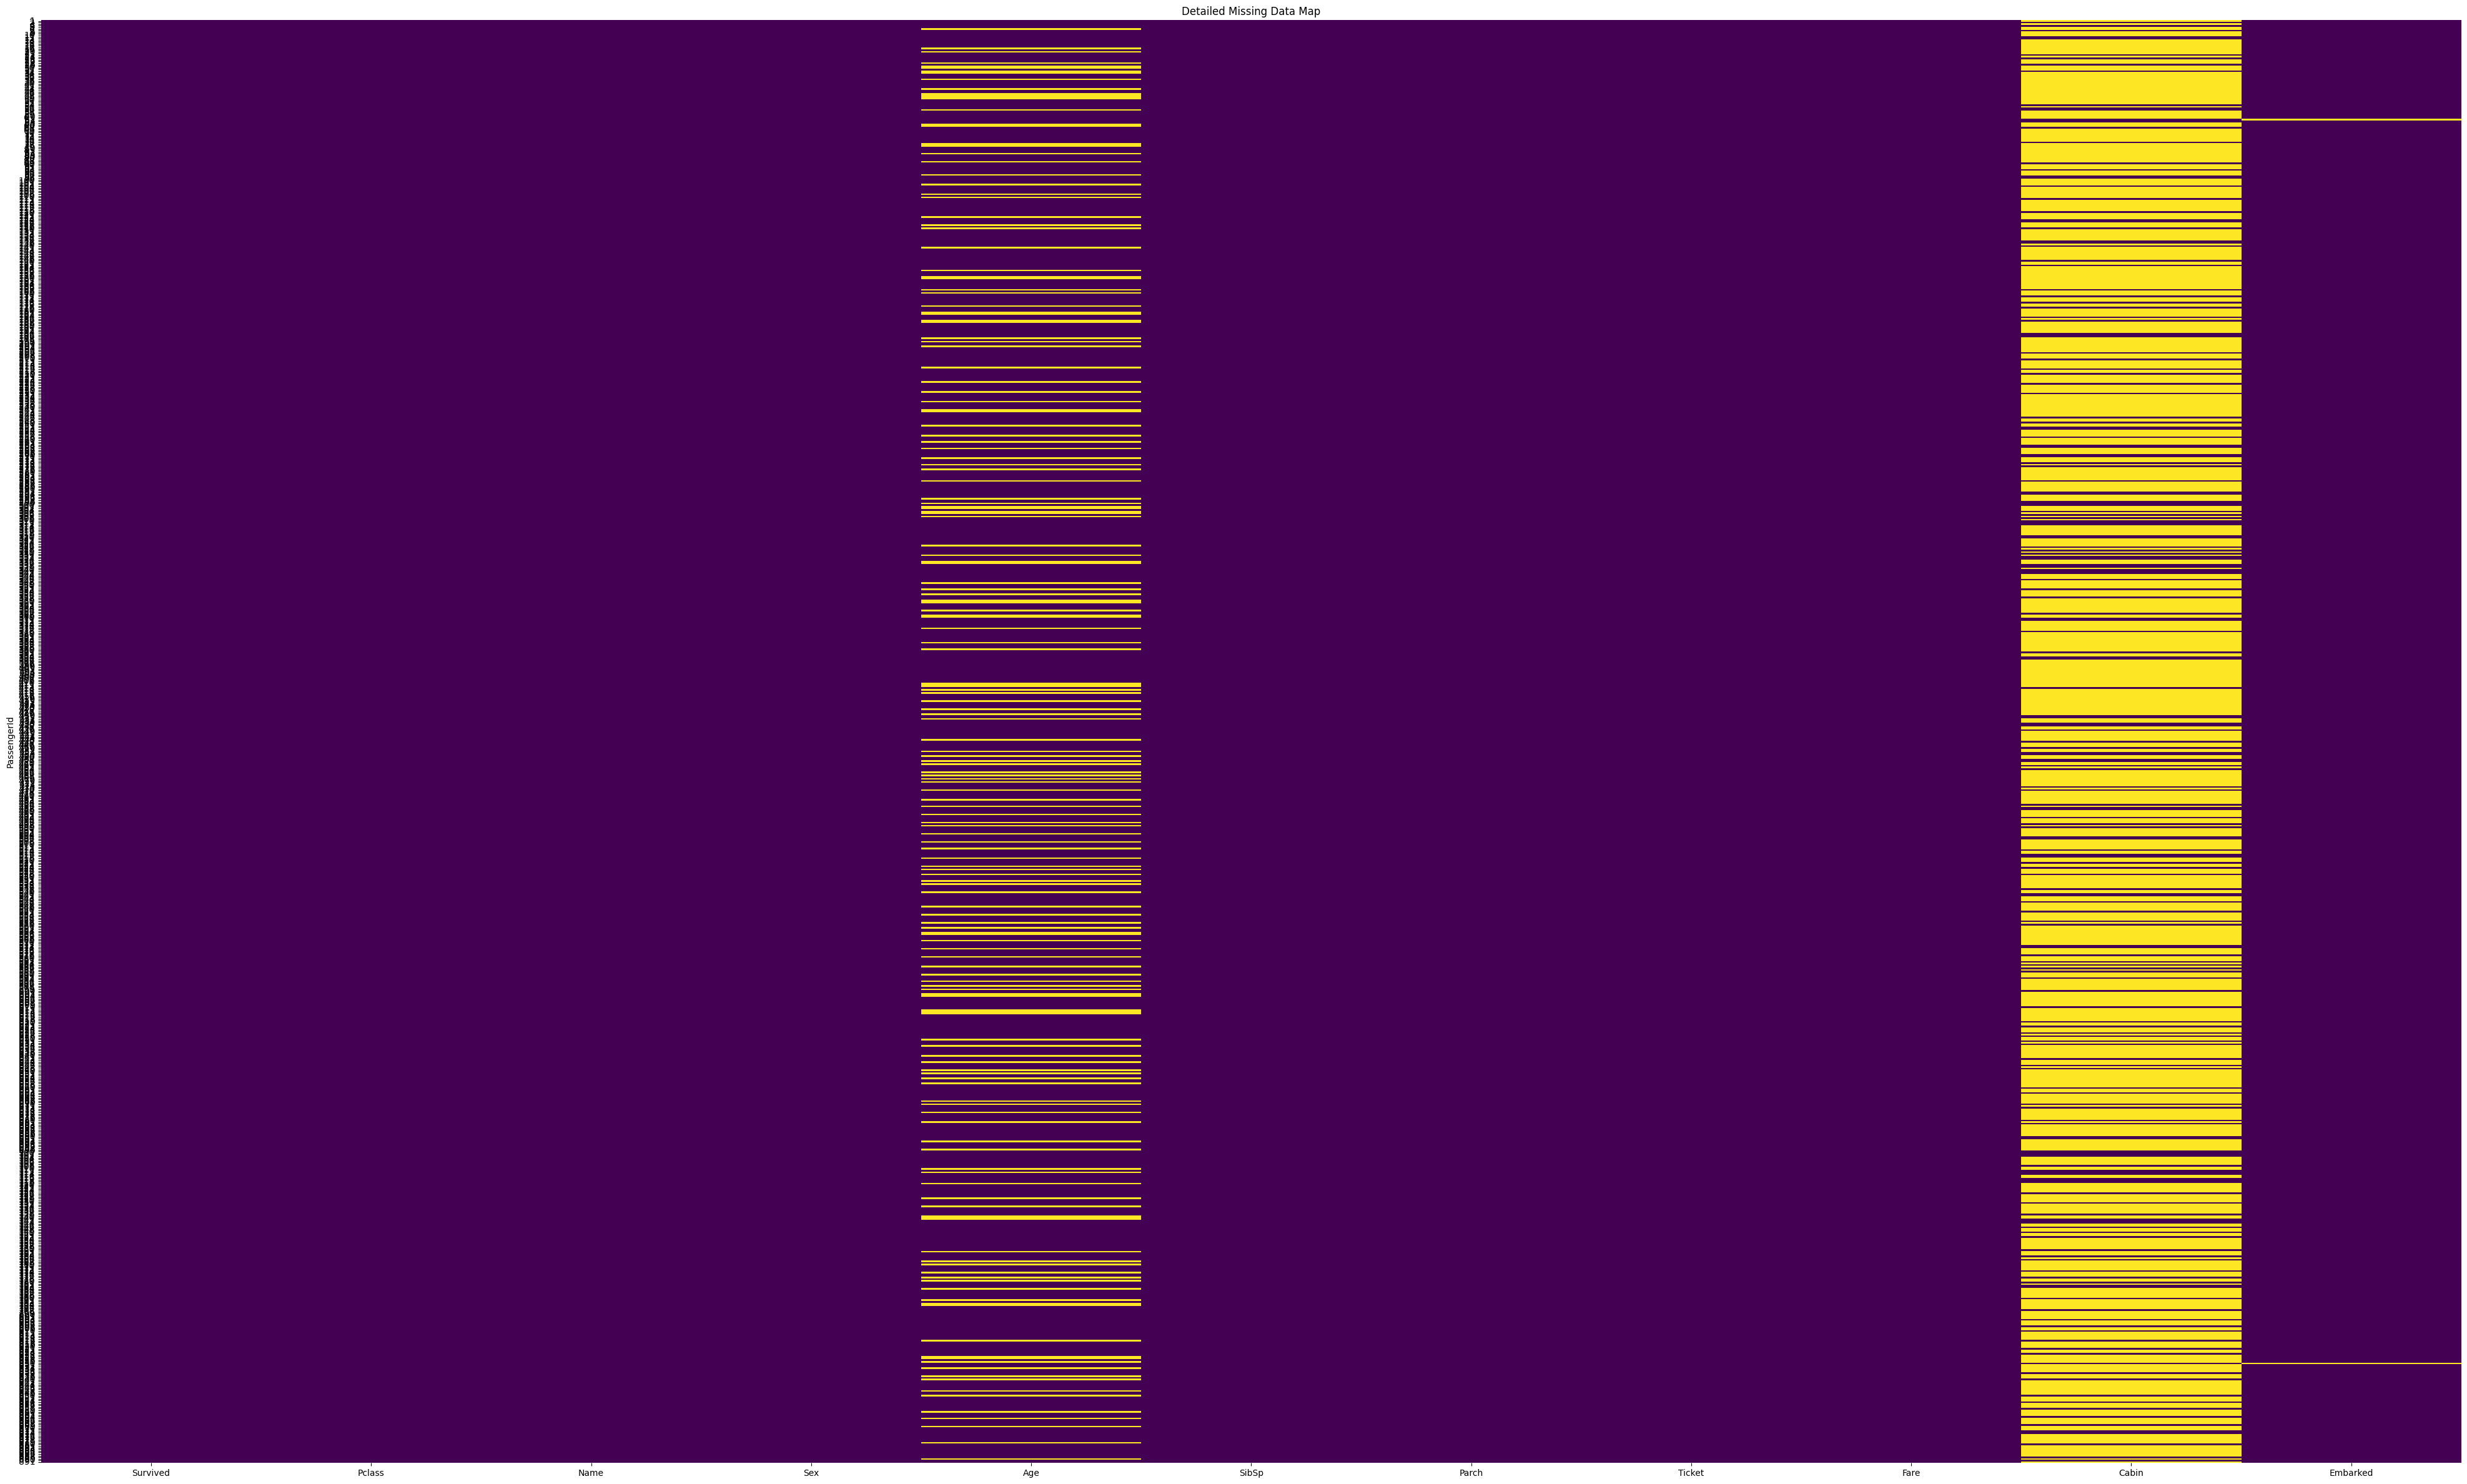

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [25]:
plt.figure(figsize=(50, 30)) 

# yticklabels=1 tells seaborn to show every 1st label (every row)
sns.heatmap(df.set_index('PassengerId').isnull(), yticklabels=1, cbar=False, cmap='viridis')

plt.title('Detailed Missing Data Map')
plt.show()

missing_counts = df.isnull().sum()

# Sort them to see the "troublemakers" at the top
print(missing_counts.sort_values(ascending=False))

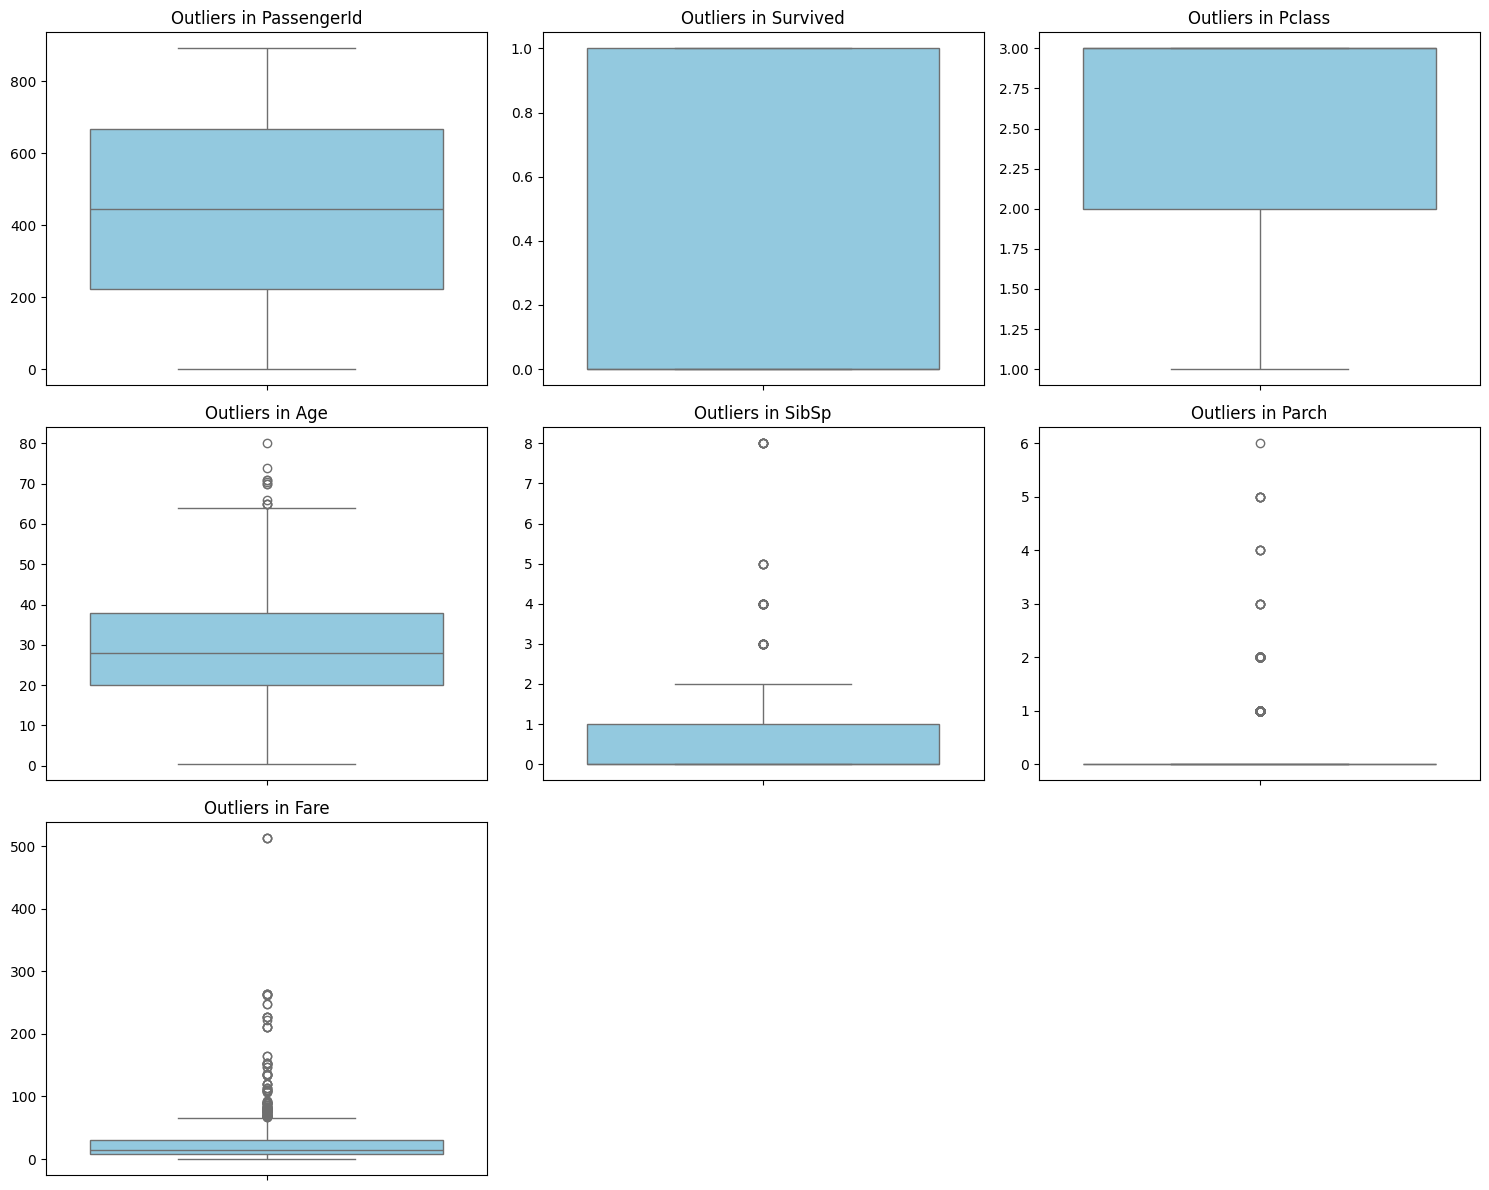

In [29]:
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Calculate the grid size (we'll do 3 plots per row)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# 3. Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Flatten the 2D grid into a 1D list for easy looping

# 4. Loop through each numeric column and plot
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outliers in {col}', fontsize=12)
    axes[i].set_ylabel('') # Clean up the axis labels

# 5. Hide any empty subplots (if you have, say, 7 plots in a 9-plot grid)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_15029/1684100732.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variable', y='value', data=df_melted, palette='magma')


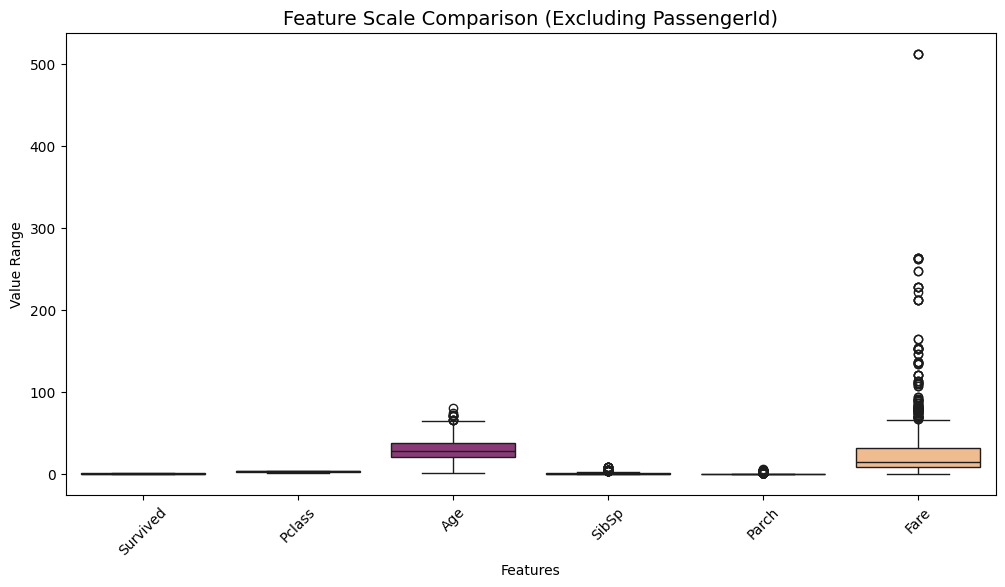

In [31]:
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Filter out 'PassengerId' if it exists in the list
# We use a list comprehension to keep everything except the ID
features_to_plot = [col for col in numeric_cols if col != 'PassengerId']

# 3. Create a temporary dataframe with only these columns and "melt" it
df_melted = df[features_to_plot].melt()

# 4. Plot the comparison
plt.figure(figsize=(12, 6))
sns.boxplot(x='variable', y='value', data=df_melted, palette='magma')

plt.title('Feature Scale Comparison (Excluding PassengerId)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Value Range')
plt.xlabel('Features')
plt.show()

Percentage of Survival:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_15029/3269358844.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set1')


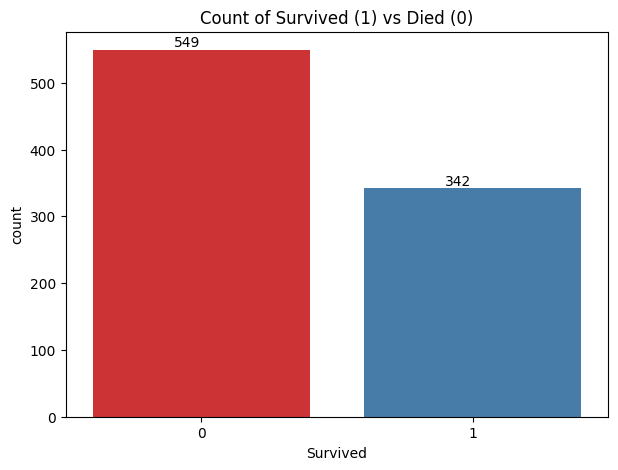

In [35]:
print("Percentage of Survival:")
print(df['Survived'].value_counts(normalize=True) * 100)
plt.figure(figsize=(7, 5))
sns.countplot(x='Survived', data=df, palette='Set1')

# Adding the exact counts on top of the bars for clarity
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 5))

plt.title('Count of Survived (1) vs Died (0)')
plt.show()

# Visualizing Key Survival Factors

A. Gender & Class (The "Big Two")

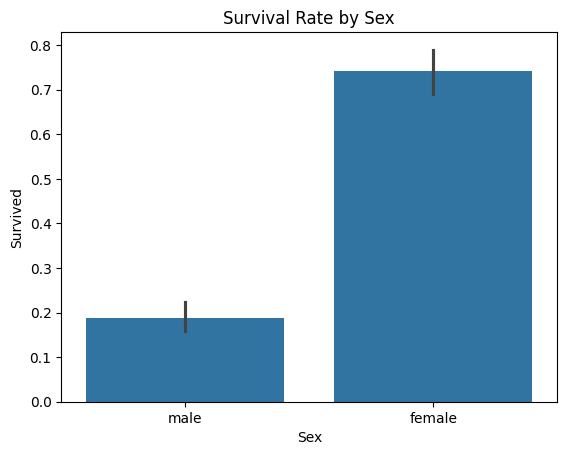

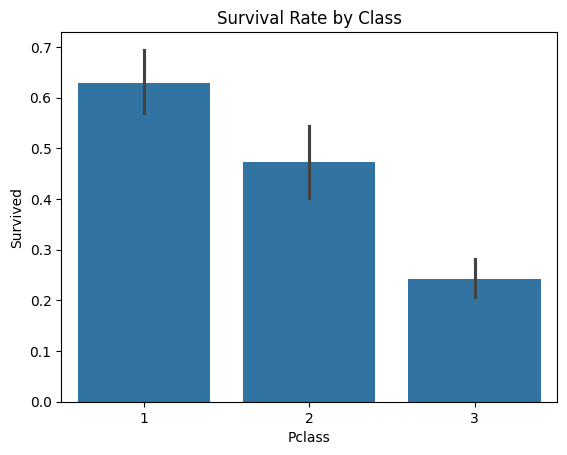

In [7]:
# Survival by Sex
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

# Survival by Pclass (Socio-economic status)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()

B. Age Distribution

Text(0.5, 1.0, 'Age Distribution of Survival')

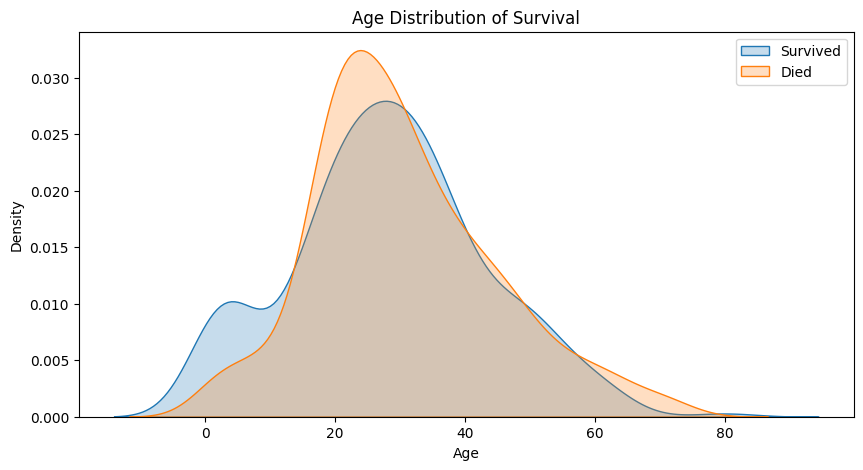

In [19]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Survived'] == 1]['Age'].dropna(), label='Survived', fill=True)
sns.kdeplot(df[df['Survived'] == 0]['Age'].dropna(), label='Died', fill=True)
plt.legend()
plt.xlabel('Age')
plt.title('Age Distribution of Survival')

# Correlation Matrix

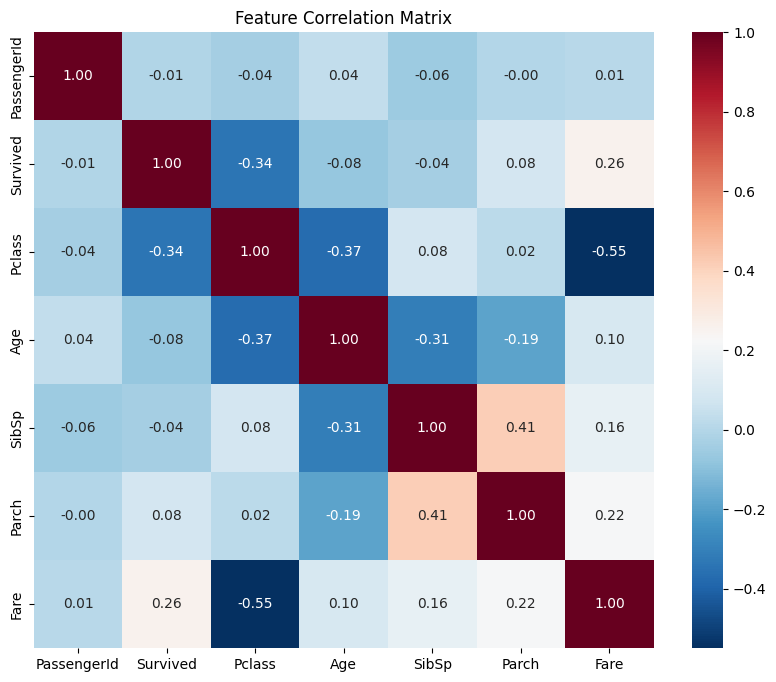

In [32]:
# Create the figure
plt.figure(figsize=(10, 8))

# Use numeric_only=True to ignore string columns like Name/Sex
corr_matrix = df.corr(numeric_only=True)

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f")

plt.title('Feature Correlation Matrix')
plt.show()